In [6]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt
import math

from os import listdir
from os.path import isfile, join

from utils.data_parsing_tools import get_lot
from utils.general_tools import pd_to_param_holder
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.modeling_tools import perform_modeling_linear
from utils.regression_tools import forecast_test_linear
from utils.display_tools import load_best_forecasts, display_predictions

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Display the forecasts and save them properly into a table

In [8]:
data = pickle.load(open("../saves_and_results/cache_lot.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [9]:
loc = "Moehne"
direction = "lot"

In [10]:
d = data[loc][direction]
y_ = d.loc[d.index.year == 2020]

### Baseline Regression

In [162]:
model_spec, forecasts = load_best_forecasts("results/baseline_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,M_Stau,M_T,Decompose,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.900339,-0.649697,0.742086,0,NaN,NaN,0,[0],[0],0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,1.024321,-0.629292,0.642542,0,NaN,NaN,0,[0],[0],0,0,0,0,NaN,250.0,7.0,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,1.192759,-0.516382,0.761347,0,NaN,NaN,0,[0],[0],0,0,0,0,dt,250.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,1.609238,-0.548639,0.533340,0,0.0,0.0,0,[0],[0],0,0,0,0,NaN,NaN,NaN,NaN,1.609238,-0.548639,0.53334,-1040.168872,sarimax


In [169]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.881711,0.705240
forest,0.674114,0.509897
sarimax,1.336078,1.079351
ada,0.755035,0.552205


In [151]:
np.where(d.index.day_of_year == 1)[0]

array([ 275,  638, 1003, 1366, 1731, 2097])

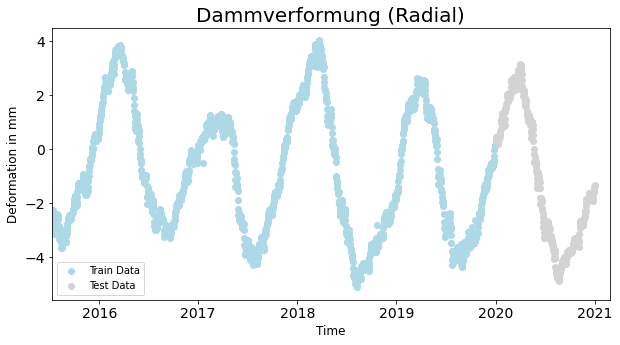

In [166]:
display_predictions(d,pd.DataFrame(), rmse, x_lim=[100,2151], alphas = [0.1,0.1,0.1,0.1])

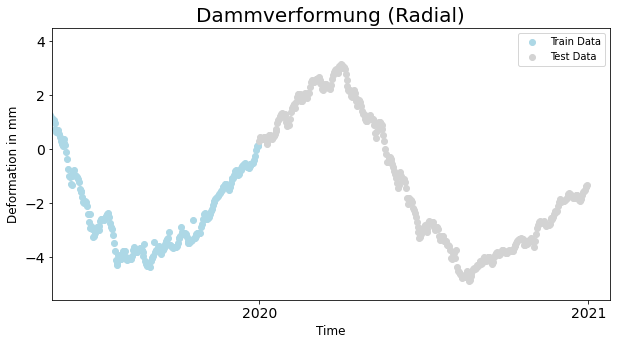

In [168]:
display_predictions(d,pd.DataFrame(), rmse, x_lim=[1500,2121], alphas = [0.1,0.1,0.1,0.1])

In [ ]:
display_predictions(d,forecasts, rmse, x_lim=[1500,2121], alphas = [0.1,0.1,0.1,0.1])

### Only one step back

In [6]:
model_spec, forecasts = load_best_forecasts("results/one_step_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.016883,-0.013370,0.042900,1,NaN,NaN,0,[0],[0],...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,0.023533,-0.013668,0.072563,1,NaN,NaN,0,[0],[0],...,0,NaN,50.0,7.0,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,0.016941,-0.018089,0.045796,1,NaN,NaN,0,[0],[0],...,0,linear,50.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,0.826776,0.652571,0.225535,1,0.0,0.0,0,[0],[0],...,0,NaN,NaN,NaN,NaN,0.083761,0.015383,0.731306,-6372.225089,sarimax


In [8]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.079652,0.059061
forest,0.107519,0.078733
sarimax,0.282940,0.217674
ada,0.081578,0.060162


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 2)[0]


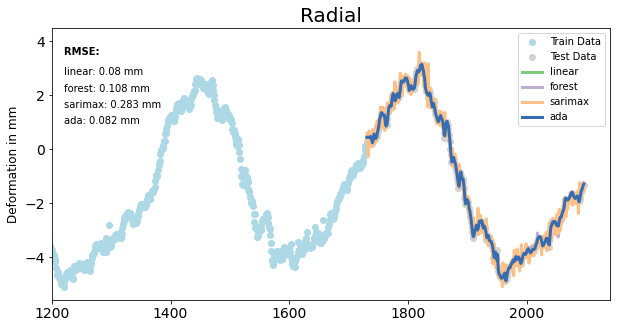

In [9]:
display_predictions(d,forecasts, rmse)

### No Sin

In [23]:
model_spec, forecasts = load_best_forecasts("results/no_sin_f", direction="lot")
model_spec.loc["linear"]

Index              Radial
MSE              0.014762
MAE              0.001286
MAPE             0.037181
P                       1
D                     NaN
Q                     NaN
F                       0
STAU                  [0]
T                 [0 1 2]
M_Stau                  0
M_T                     1
Decompose               1
Interaction             1
Estimator             NaN
n_estimator           NaN
max_depth             NaN
learning_rate         NaN
MSE_1step             NaN
MAE_1step             NaN
AIC                   NaN
MAPE_1step            NaN
Index_2            linear
Name: linear, dtype: object

In [12]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.067454,0.048065
forest,0.089477,0.065875
sarimax,0.070335,0.051277
ada,0.080207,0.058464


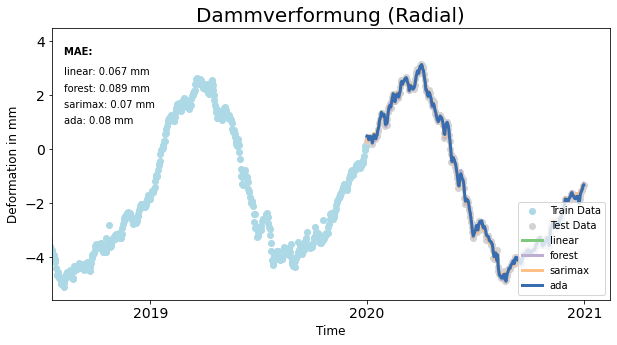

In [15]:
display_predictions(d,forecasts, rmse, key = "Radial", x_lim=[1200,2140],alphas=[1,1,1,1])

### No Lookback but full variable set

In [10]:
model_spec, forecasts = load_best_forecasts("results/no_autoreg_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.074288,0.126537,0.133000,0,NaN,NaN,2,[0 1 2],[0 1 2],...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,0.182353,-0.340524,0.376315,0,NaN,NaN,2,[0],[0],...,0,NaN,250.0,NaN,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,0.085493,-0.080690,0.281120,0,NaN,NaN,1,[0 1 2],[0 1 2],...,1,linear,250.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,0.080039,0.094179,0.109193,0,0.0,0.0,2,[0],[0 1 2],...,0,NaN,NaN,NaN,NaN,0.080039,0.094179,0.109193,-3278.978847,sarimax


In [13]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.376380,0.318648
forest,0.387583,0.310237
sarimax,0.380118,0.324679
ada,0.440197,0.370851


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 2)[0]


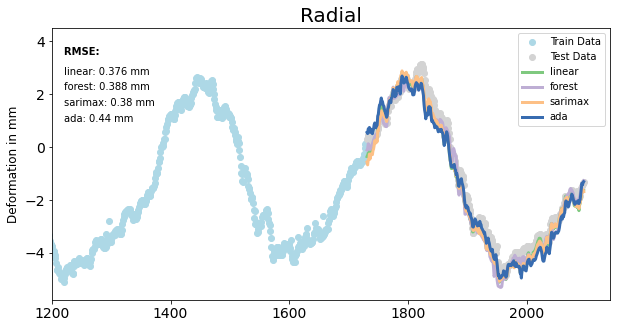

In [14]:
display_predictions(d,forecasts, rmse)

### Full search no interaction effect

In [17]:
model_spec, forecasts = load_best_forecasts("results/full_search_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.014910,0.004036,0.049793,1,NaN,NaN,2,[0],[0 1 2],...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,0.017530,-0.003106,0.046325,2,NaN,NaN,1,[0],[0 1 2],...,0,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,0.014151,0.000963,0.055070,2,NaN,NaN,1,[0 1],[0 1 2],...,0,linear,50.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,0.050189,0.041414,0.049580,1,1.0,1.0,2,[0],[0 1],...,0,NaN,NaN,NaN,NaN,0.017094,0.000775,0.108067,-9903.43726,sarimax


In [18]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.068365,0.049484
forest,0.088739,0.064940
sarimax,0.069985,0.050676
ada,0.084386,0.064140


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 2)[0]


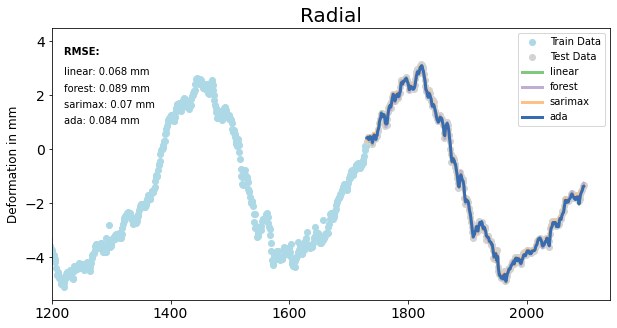

In [20]:
display_predictions(d,forecasts, rmse)

### Finally: Full search always interaction effect

In [22]:
model_spec, forecasts = load_best_forecasts("results/full_search_interaction_f", direction="lot")
model_spec

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
linear,Radial,0.014741,0.002966,0.047009,1,NaN,NaN,2,[0],[0 1 2],...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear
forest,Radial,0.017299,-0.005585,0.046552,2,NaN,NaN,2,[0 1 2],[0 1 2],...,1,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,forest
ada,Radial,0.014097,-0.027486,0.045406,2,NaN,NaN,2,[0],[0 1 2],...,1,linear,250.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
sarimax,Radial,0.049762,0.042520,0.049068,1,1.0,1.0,2,[0],[0 1],...,1,NaN,NaN,NaN,NaN,0.01706,0.000771,0.107731,-9901.71942,sarimax


In [23]:
rmse = pd.DataFrame(np.sqrt(((forecasts - y_.values) **2).mean().values), index= forecasts.columns, columns= ["RMSE"])
mae = pd.DataFrame((np.abs(forecasts - y_.values).mean().values), index= forecasts.columns, columns= ["MAE"])

pd.concat([rmse, mae],axis=1)

,RMSE,MAE
linear,0.067038,0.048208
forest,0.089965,0.065747
sarimax,0.069989,0.050686
ada,0.087814,0.068128


In [49]:
np.abs(forecasts[["linear",	"sarimax"]].mean(axis=1) - y_.values[:,0]).mean()

0.047307022694319766

/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 2)[0]


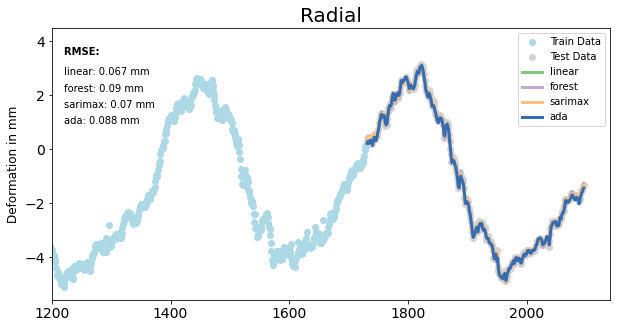

In [50]:
display_predictions(d,forecasts, rmse)

### Rebuild model

In [16]:
# some ugly refractor because of loading: 
for y in ["T", "STAU"]:
    stack = []
    for x in model_spec.index:
            stack.append(np.array(model_spec.loc[x,  y][1:-1].split(" ")).astype(int))
    model_spec[y] = stack

In [17]:
model_spec["Index"] = model_spec.index
combo = pd_to_param_holder(model_spec, "linear")

In [18]:
(train,
test,
max_data,
min_data,
trend,
seasonality,
test_trend,
test_seasonality) = (
full_preprocessing_pipeline(data["Moehne"]["lot"], exogs["Moehne"], combo, model_search=False)
)

/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/data_processing_tools.py:219: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the operation. Dropped columns were Index(['datetime'], dtype='object')
  exog_stau = exog.rolling(mean_period[1], closed="left").mean()
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [19]:
model, trend_step = perform_modeling_linear(train[0]["Radial"], train[1], combo)
pred = forecast_test_linear(test[0],test[1], combo, model, trend_step)

In [20]:
p = "Radial"
Y, Y_hat = bring_to_original_range(
    test[0][p],
    pred[0],
    max_data[p],
    min_data[p],
    (test_trend[p] if isinstance(trend, pd.DataFrame) else None),
    (test_seasonality[p] if isinstance(seasonality, pd.DataFrame) else None),
    data["Moehne"]["lot"],
    p
)

In [21]:
math.sqrt(((Y_hat.values- y_.values[:,0])**2).mean()),  np.abs(Y_hat.values- y_.values[:,0]).mean()

(0.06745364507924446, 0.04806508185564268)

In [22]:
names = perform_modeling_linear(train[0]["Radial"], train[1], combo, return_temporary=True).columns
final = model.summary().tables[1]
pd.DataFrame(final.data[1:], index = names)

,0,1,2,3,4,5,6
T_mean_1_0,x1,-0.0370,0.004,-9.584,0.000,-0.045,-0.029
W_0,x2,0.0658,0.005,12.135,0.000,0.055,0.076
T_0,x3,0.5023,0.117,4.280,0.000,0.272,0.733
T_1,x4,-0.0370,0.004,-9.584,0.000,-0.045,-0.029
T_2,x5,0.0983,0.006,16.554,0.000,0.087,0.110
INTER,x6,-0.6237,0.119,-5.249,0.000,-0.857,-0.391
1,x7,0.9386,0.005,191.735,0.000,0.929,0.948
const,const,0.0466,0.003,15.712,0.000,0.041,0.052
trend,x8,0.0039,0.002,2.183,0.029,0.000,0.007
